In [ ]:
# ============================================================
# SETUP: Configure paths and imports for reproducibility
# ============================================================
import os
import sys

# Auto-detect repository root by walking up directories
_current = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_current, 'dcpbst_package')):
        break
    _current = os.path.dirname(_current)
else:
    _current = os.getcwd()

REPO_ROOT = _current
DATA_DIR = os.path.join(REPO_ROOT, 'data')
FIGURES_DIR = os.path.join(REPO_ROOT, 'figures')
RESULTS_DIR = os.path.join(REPO_ROOT, 'saved_results')
CONFIGS_DIR = os.path.join(REPO_ROOT, 'configs')

# Change to repo root so relative paths work
os.chdir(REPO_ROOT)

# Add dcpbst_package to import path
sys.path.insert(0, os.path.join(REPO_ROOT, 'dcpbst_package'))
print(f'Repo root: {REPO_ROOT}')
print(f'Data dir: {DATA_DIR}')

# Set random seeds for reproducibility
import numpy as np
import torch
import random
seed = 100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    device = 'cuda'
else:
    device = 'cpu'
print(f'Device: {device}')


In [1]:
!fuser -v /dev/nvidia* |awk '{for(i=1;i<=NF;i++)print "kill -9 " $i;}' | sh

/bin/bash: fuser: command not found


In [2]:
import sys
import os
os.chdir(REPO_ROOT)
from dcpbst.hist_features import get_features
from dcpbst.utils import *
from dcpbst.model_829_copy import Dcpbst
from PIL import Image
import pandas as pd
import numpy as np
import scanpy as scs
import os
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
Image.MAX_IMAGE_PIXELS = None
Image.MAX_IMAGE_PIXELS = None
import torch
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import random
from dcpbst.evals import *
from dcpbst.preprocess import *
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import json
from tqdm import tqdm
import networkx as nx
import scipy.sparse as sp
from torch.backends import cudnn
import torchvision.models as models
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.csc import csc_matrix
from scipy.sparse.csr import csr_matrix
import torchvision.transforms as transforms
import cv2
from sklearn.preprocessing import LabelEncoder
import importlib_metadata 
from sklearn.metrics.cluster import contingency_matrix
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, \
    homogeneity_completeness_v_measure, calinski_harabasz_score, davies_bouldin_score
from pathlib import Path
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
seed=100
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print("CUDA is available. GPU:", torch.cuda.get_device_name(0))
else:
    device = 'cpu'
    print("CUDA is not available. Using CPU.")

data_file=os.path.join(DATA_DIR, 'mouse_Hypothalamus/MERFISH_0.14_20251020183913_1.h5ad')
adata = sc.read_h5ad(data_file)
adata.var_names_make_unique()
print(adata)

CUDA is available. GPU: NVIDIA GeForce RTX 4060 Ti
AnnData object with n_obs × n_vars = 5926 × 155
    obs: 'cell_class', 'neuron_class', 'domain', 'Region', 'ground_truth'
    uns: 'domain_colors'
    obsm: 'spatial'


/root/miniconda3/envs/miso/lib/python3.7/site-packages/outdated/utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.5.5.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


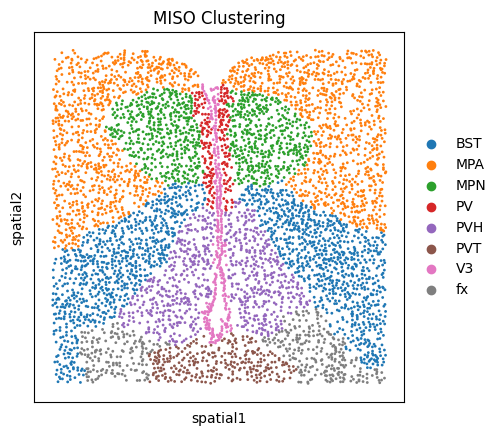

In [3]:
sc.pl.spatial(
    adata,
    # <<< Modified: color parameter only provides a column name string >>>
    color="ground_truth",
    # <<< Modified: title parameter also only provides a title string >>>
    title=f'DCPBST Clustering',
    spot_size=15,
)

AnnData object with n_obs × n_vars = 5926 × 155
    obs: 'cell_class', 'neuron_class', 'domain', 'Region', 'ground_truth'
    uns: 'domain_colors'
    obsm: 'spatial'
Loaded data: (5926, 155)
scrna shape: (5926, 155)
spatial shape: (5926, 2)
8


/root/miniconda3/envs/miso/lib/python3.7/site-packages/scanpy/preprocessing/_highly_variable_genes.py:64: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  UserWarning,
/root/miniconda3/envs/miso/lib/python3.7/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


发现 'ground_truth'，准备用于监督学习的标签...
正在构建空间、基因和图像特征的邻接矩阵...
警告：在 adata.obsm 中未找到 'feat_img'，跳过图像特征图的构建。
所有邻接矩阵构建完成。
Classifier created: Input dim=256, Output dim=8
Initializing Modal Robustness Diagnoser...
Initial weights of encoders have been saved.


Training Miso Model:   0%|          | 0/800 [00:00<?, ?it/s]


Epoch 10/800 | Total Loss: 324.8975 | Recon: 1.1124 | KL: 587.8756 | InfoNCE: 8.8267 | DGI: 34.5155|Proxy: 2.1520|Classfity: 21.9638

Epoch 20/800 | Total Loss: 133.8363 | Recon: 0.9560 | KL: 484.5339 | InfoNCE: 9.0028 | DGI: 33.7311|Proxy: 2.1579|Classfity: 4.0170

Epoch 30/800 | Total Loss: 104.6799 | Recon: 0.8925 | KL: 358.7336 | InfoNCE: 8.8728 | DGI: 34.5388|Proxy: 2.0672|Classfity: 2.4782

Epoch 40/800 | Total Loss: 85.9359 | Recon: 0.8702 | KL: 263.8390 | InfoNCE: 8.8022 | DGI: 34.5388|Proxy: 2.0600|Classfity: 1.6000

Epoch 50/800 | Total Loss: 74.1474 | Recon: 0.8670 | KL: 195.7720 | InfoNCE: 8.7818 | DGI: 34.5388|Proxy: 2.0888|Classfity: 1.1056

Epoch 60/800 | Total Loss: 68.1784 | Recon: 0.8746 | KL: 150.3597 | InfoNCE: 8.7805 | DGI: 34.5388|Proxy: 2.0771|Classfity: 0.9572

Epoch 70/800 | Total Loss: 64.1042 | Recon: 0.8838 | KL: 121.8129 | InfoNCE: 8.7617 | DGI: 34.5388|Proxy: 2.0598|Classfity: 0.8342

Epoch 80/800 | Total Loss: 60.5747 | Recon: 0.8878 | KL: 103.7098 | Inf

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
'Mclust' model object: (EEE,8) 

Available components: 
 [1] "call"           "data"           "modelName"      "n"             
 [5] "d"              "G"              "BIC"            "loglik"        
 [9] "df"             "bic"            "icl"            "hypvol"        
[13] "parameters"     "z"              "classification" "uncertainty"   

ARI=0.5568734840147228, NMI=0.6228976681813615,Purity=0.7423219709753628,V_Measure=0.6228976681813615
  Sample       ARI       NMI    Purity  Homogeneity  Completeness  V_Measure  \
0    NaN  0.556873  0.622898  0.742322     0.614206      0.631839   0.622898   

  methods  
0     NaN  
AnnData object with n_obs × n_vars = 5926 × 155
    obs: 'cell_class', 'neuron_class', 'domain', 'Region', 'ground_truth', 'mclust'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'domain_colors', 'hvg', 'log1p'
    obsm

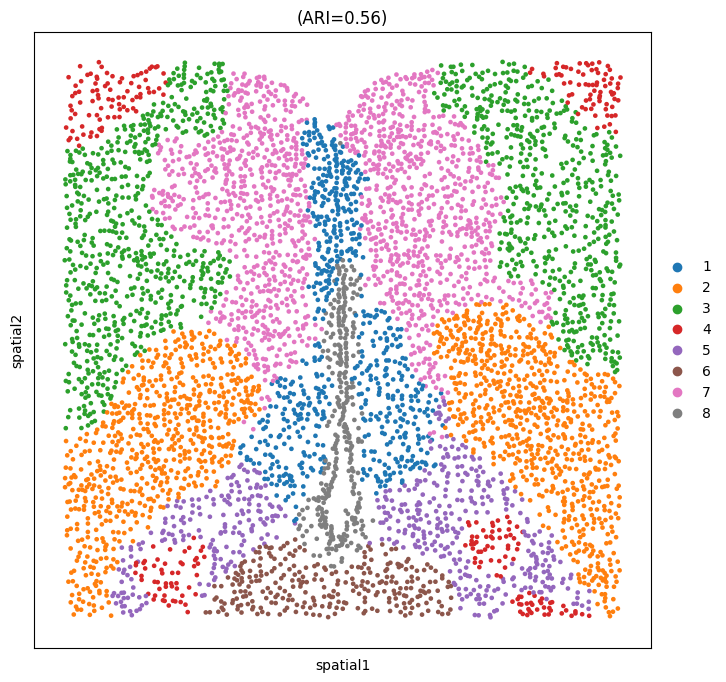

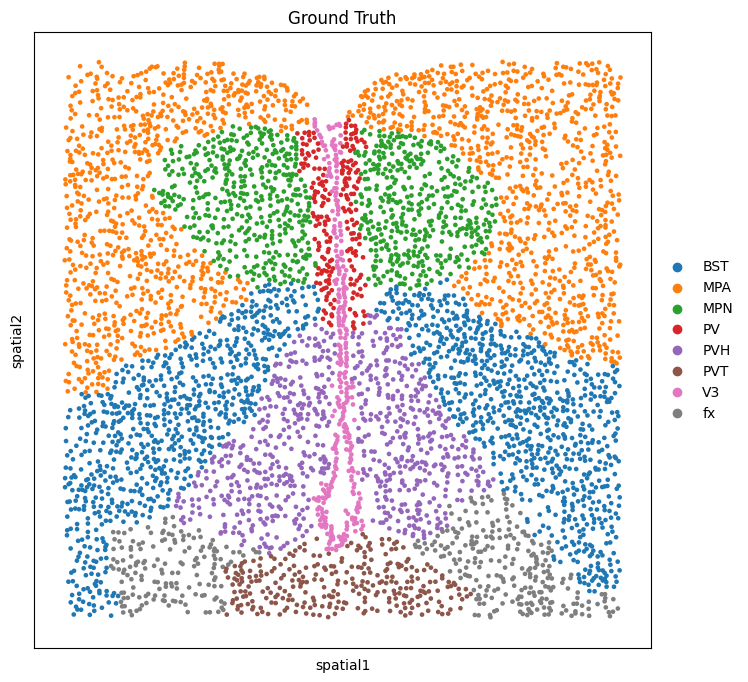

In [ ]:

def preprocess_rna_dlpfc(adata):
    sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata[:, adata.var['highly_variable']]



def purity_score(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(cm, axis=0)) / np.sum(cm)


def search_res(adata, n_clusters, method='leiden', use_rep='emb', start=0.1, end=3.0, increment=0.01):
    print('Searching resolution...')
    label = 0
    sc.pp.neighbors(adata, n_neighbors=50, use_rep=use_rep)
    for res in sorted(list(np.arange(start, end, increment)), reverse=True):
        if method == 'leiden':
            sc.tl.leiden(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['leiden']).leiden.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        elif method == 'louvain':
            sc.tl.louvain(adata, random_state=0, resolution=res)
            count_unique = len(pd.DataFrame(adata.obs['louvain']).louvain.unique())
            print('resolution={}, cluster number={}'.format(res, count_unique))
        if count_unique == n_clusters:
            label = 1
            break

    assert label == 1, "Resolution is not found. Please try bigger range or smaller step!."

    return res

# 2. Define clustering-related metric calculation
def refine_label(adata, radius=50, key='label'):
    n_neigh = radius
    new_type = []
    old_type = adata.obs[key].values

    # calculate distance
    position = adata.obsm['spatial']
    distance = ot.dist(position, position, metric='euclidean')

    n_cell = distance.shape[0]

    for i in range(n_cell):
        vec = distance[i, :]
        index = vec.argsort()
        neigh_type = []
        for j in range(1, n_neigh + 1):
            neigh_type.append(old_type[index[j]])
        max_type = max(neigh_type, key=neigh_type.count)
        new_type.append(max_type)

    new_type = [str(i) for i in list(new_type)]

    return new_type

def mclust_R(adata, num_cluster, modelNames='EEE', used_obsm='emb_pca', random_seed=2024):
    """\
    Clustering using the mclust algorithm.
    The parameters are the same as those in the R package mclust.
    """

    np.random.seed(random_seed)
    import rpy2.robjects as robjects
    robjects.r.library("mclust")

    import rpy2.robjects.numpy2ri
    rpy2.robjects.numpy2ri.activate()
    r_random_seed = robjects.r['set.seed']
    r_random_seed(random_seed)
    rmclust = robjects.r['Mclust']

    res = rmclust(rpy2.robjects.numpy2ri.numpy2rpy(adata.obsm[used_obsm]), num_cluster, modelNames)
    print(res)
    mclust_res = np.array(res[-2])

    adata.obs['mclust'] = mclust_res
    adata.obs['mclust'] = adata.obs['mclust'].astype('int')
    adata.obs['mclust'] = adata.obs['mclust'].astype('category')
    return adata

def calculate_clustering_matrix(df, y_pred, ground_truth):
    ari = adjusted_rand_score(y_pred, ground_truth)
    nmi = normalized_mutual_info_score(y_pred, ground_truth)
    purity = purity_score(y_pred, ground_truth)
    homogeneity, completeness, v_measure = homogeneity_completeness_v_measure(y_pred, ground_truth)
    print("ARI={}, NMI={},Purity={},V_Measure={}".format(ari, nmi,purity,v_measure))

    new_row = pd.DataFrame([{
        'ARI': ari,
        'NMI': nmi,
        'Purity': purity,
        'Homogeneity': homogeneity,
        'Completeness': completeness,
        'V_Measure': v_measure
        # 'Sample' and 'methods' columns can be added later or adjusted as needed
    }])

    # 2. Use pd.concat to merge new rows into existing DataFrame
    df = pd.concat([df, new_row], ignore_index=True)
    
    return df

def clustering(adata, n_clusters=7, radius=50, key='emb', method='mclust', start=0.1, end=3.0, increment=0.01,
               refinement=False):# Changed a parameter setting
    # PCA dimensionality reduction done before clustering
    pca = PCA(n_components=20, random_state=2024)
    embedding = pca.fit_transform(adata.obsm[key].copy())
    adata.obsm['emb_pca'] = embedding


    if method == 'mclust':
        adata = mclust_R(adata, used_obsm='emb_pca', num_cluster=n_clusters)
        adata.obs['domain'] = adata.obs['mclust']
    elif method == 'kmeans':
        kmeans = KMeans(n_clusters=n_clusters).fit(embedding)
        kmeans_result = [i + 1 for i in kmeans.labels_]
        adata.obs['domain'] = list(map(lambda x: str(x), kmeans_result))
    elif method == 'leiden':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.leiden(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['leiden']
    elif method == 'louvain':
        res = search_res(adata, n_clusters, use_rep='emb_pca', method=method, start=start, end=end, increment=increment)
        sc.tl.louvain(adata, random_state=0, resolution=res)
        adata.obs['domain'] = adata.obs['louvain']

    if refinement:
        new_type = refine_label(adata, radius, key='domain')
        adata.obs['domain'] = new_type




# Main execution function
def run_dcpbst_pipeline(data_path, device='cuda',feature=None):
    df = pd.DataFrame(columns=['Sample', 'ARI', 'NMI', 'Purity', 'Homogeneity', 'Completeness', 'V_Measure', 'methods'])
    adata_path = os.path.join(DATA_DIR, 'mouse_Hypothalamus/MERFISH_0.14_20251020183913_1.h5ad')
    adata = sc.read_h5ad(data_file)
    adata.var_names_make_unique()
    print(adata)
    adata = adata[~pd.isnull(adata.obs["ground_truth"])]
    print(f"Loaded data: {adata.shape}")
    adata = preprocess_rna_dlpfc(adata)
    if scipy.sparse.issparse(adata.X):
       scrna=adata.X.A
    else:
       scrna=adata.X
    print("scrna shape:", scrna.shape)
 spatial = adata.obsm['spatial'] # directlyGet (n,2) Coordinate matrix
 print("spatial shape:", spatial.shape) # VerifyOutput (n, 2)
    # image_emb=adata.obsm['feat_img']
    n_clusters=len(set(adata.obs["ground_truth"]))
    k=n_clusters
    print(k)
    model = Dcpbst([scrna,spatial],sparse=False,device=device,n_clusters=n_clusters,adata=adata,neighbors=6)
    
    embedding=model.fit()
    adata.obsm['emb']=embedding
    alpha_data = model.get_alpha_history_for_heatmap()
# 3. Pass it into the clustering method
    radius = 40
    tool = 'mclust'
    if tool == 'mclust':
        clustering(adata, n_clusters=k, radius=radius, method=tool,
                refinement=True)  # For DLPFC dataset, we use optional refinement step.
    elif tool == 'kmeans':
       clustering(adata, n_clusters=k, method=tool)
    elif tool in ['leiden', 'louvain']:
        clustering(adata, n_clusters=k, radius=radius, method=tool, start=0.1, end=2.0, increment=0.01,
                refinement=True)
        print(f"Loaded data: {adata.shape}")
    df = calculate_clustering_matrix(df, adata.obs['domain'], adata.obs['ground_truth'])
    print(df)
    df.to_csv('xiaqiu-0830.csv')

    return adata, model, df


adata, alpha_data,model,eval_df = run_dcpbst_pipeline(os.path.join(DATA_DIR, 'mouse_Hypothalamus'), device='cuda')

final_clusters = adata.obs['domain']

# Define column name for clustering results
try:
    ari_score = eval_df['ARI'].iloc[0]  # Here eval_df is the cluster evaluation result
except:
    ari_score = 0.0

print(adata)

# Draw spatial distribution of clustering results
plt.rcParams["figure.figsize"] = (8,8) # Adjustable plot size
sc.pl.spatial(
    adata,
 color="domain", # Use domain Column as color basis(clusters label)
 title=f'(ARI={ari_score:.2f})', # Display ARI score
    spot_size=15)
sc.pl.spatial(
    adata,
 color="ground_truth", # Use domain Column as color basis(clusters label)
 title="Ground Truth", # Display ARI score
    spot_size=15)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(alpha_data['alpha_matrix'].T, 
            xticklabels=alpha_data['epochs'],
            yticklabels=alpha_data['view_names'],
            cmap='viridis', 
            annot=True, 
            fmt='.4f',
            cbar_kws={'label': 'Alpha Value'})
plt.xlabel('Epoch')
plt.ylabel('View')
plt.title('Modal Weight Modulation (Alpha Values)')
plt.tight_layout()
plt.show()